# Projections and Components

## Purpose

Understand projection as the part of one vector that lies in the direction of another, and use it to split a vector into parallel and perpendicular components.

This notebook builds on the dot product and cosine similarity notebook.

The goal is not to memorise a formula in isolation. The goal is to connect the formula to a visual idea:

> projection tells us where one vector lands on the direction of another vector.

## Helpers

These helpers keep the plotting code out of the main learning examples.

The diagrams in this notebook use 2D vectors because they are easy to visualise, but the projection ideas apply in higher dimensions too.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def setup_vector_plot(xlim=(-1, 6), ylim=(-1, 5), figsize=(5, 5)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True)
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    return fig, ax


def draw_vector(
    ax,
    v,
    origin=(0, 0),
    label=None,
    label_offset=(0.1, 0.1),
    color=None,
    width=0.006,
):
    origin = np.array(origin, dtype=float)
    v = np.array(v, dtype=float)

    ax.quiver(
        origin[0],
        origin[1],
        v[0],
        v[1],
        angles="xy",
        scale_units="xy",
        scale=1,
        color=color,
        width=width,
    )

    if label:
        end = origin + v
        ax.text(
            end[0] + label_offset[0],
            end[1] + label_offset[1],
            label,
            fontsize=10,
        )


def draw_dashed_line(ax, start, end, color=None):
    start = np.array(start, dtype=float)
    end = np.array(end, dtype=float)

    ax.plot(
        [start[0], end[0]],
        [start[1], end[1]],
        linestyle="--",
        color=color,
    )


def projection_of(a, b):
    a = np.array(a, dtype=float)
    b = np.array(b, dtype=float)

    return ((a @ b) / (b @ b)) * b


def perpendicular_component_of(a, b):
    return np.array(a, dtype=float) - projection_of(a, b)

## Recap: dot product and cosine similarity

The dot product measures how aligned two vectors are.

For two vectors \(a\) and \(b\):

$$
a \cdot b = \|a\| \|b\| \cos(\theta)
$$

So the dot product combines:

- the length of \(a\)
- the length of \(b\)
- the direction/alignment between them

Cosine similarity removes the effect of length:

$$
\cos(\theta) = \frac{a \cdot b}{\|a\| \|b\|}
$$

Projection builds directly on this idea.

In [3]:
a = np.array([4, 3])
b = np.array([5, 0])

dot_ab = a @ b
norm_a = np.linalg.norm(a)
norm_b = np.linalg.norm(b)
cosine_similarity = dot_ab / (norm_a * norm_b)

print("a:", a)
print("b:", b)
print("a · b:", dot_ab)
print("||a||:", norm_a)
print("||b||:", norm_b)
print("cosine similarity:", cosine_similarity)

a: [4 3]
b: [5 0]
a · b: 20
||a||: 5.0
||b||: 5.0
cosine similarity: 0.8


## What does projection mean?

A projection answers the question:

> How much of one vector lies in the direction of another vector?

In this notebook, I will use the following language:

- the **object vector** is the vector being projected
- the **target vector** is the vector being projected onto

Projection can mean two closely related things.

The **scalar projection** is a signed number: how far the object vector reaches in the target direction.

The **vector projection** is a vector: the actual target-aligned component of the object vector.

When people simply say “the projection of \(a\) onto \(b\)”, they often mean the vector projection:

$$
\operatorname{proj}_{b}(a)
$$

This means:

> the projection of object vector \(a\) onto target vector \(b\)

This notebook will introduce both meanings separately.

The vector projection does not keep the whole original vector. It keeps only the part of the object vector that lies along the target direction.

The scalar projection records the signed length of that part.

## Axis-aligned example: seeing the landing point

Start with an intentionally friendly example:

$$
a = \begin{bmatrix}4 \\ 3\end{bmatrix}
$$

$$
b = \begin{bmatrix}5 \\ 0\end{bmatrix}
$$

The target vector \(b\) points along the x-axis.

That makes the projection easy to see: if \(a\) is dropped perpendicularly onto the line through \(b\), it lands at \([4, 0]\).

So in this example, the vector projection should be:

$$
\operatorname{proj}_{b}(a) = \begin{bmatrix}4 \\ 0\end{bmatrix}
$$

The leftover perpendicular part should be:

$$
a - \operatorname{proj}_{b}(a) = \begin{bmatrix}0 \\ 3\end{bmatrix}
$$

In [4]:
a = np.array([4, 3])
b = np.array([5, 0])

vector_projection = projection_of(a, b)
perpendicular_component = perpendicular_component_of(a, b)

print("object vector a:", a)
print("target vector b:", b)
print("projection of a onto b:", vector_projection)
print("perpendicular leftover:", perpendicular_component)

object vector a: [4 3]
target vector b: [5 0]
projection of a onto b: [4. 0.]
perpendicular leftover: [0. 3.]


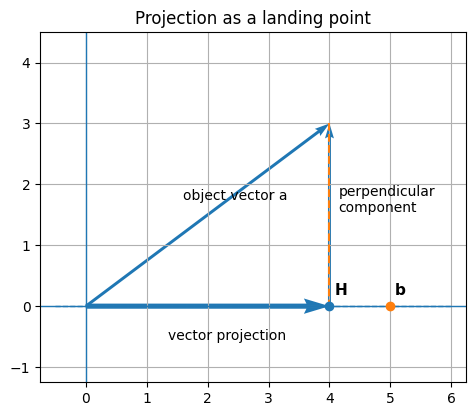

In [5]:
a = np.array([4, 3])
b = np.array([5, 0])

unit_b = b / np.linalg.norm(b)
scalar_projection = a @ unit_b
vector_projection = scalar_projection * unit_b
perpendicular_component = a - vector_projection

fig, ax = setup_vector_plot(xlim=(-0.75, 6.25), ylim=(-1.25, 4.5), figsize=(5.5, 4.8))

# Target direction / base line
ax.plot([-0.5, 6], [0, 0], linestyle="--", linewidth=1)

# Main vectors/components
draw_vector(ax, a, width=0.007)
draw_vector(ax, vector_projection, width=0.012)
draw_vector(ax, perpendicular_component, origin=vector_projection, width=0.007)

# Perpendicular guide
draw_dashed_line(ax, a, vector_projection)

# Key points
ax.scatter(vector_projection[0], vector_projection[1], zorder=4)
ax.scatter(b[0], b[1], zorder=4)

# Manual labels
ax.text(1.6, 1.75, "object vector a", fontsize=10)
ax.text(1.35, -0.55, "vector projection", fontsize=10)
ax.text(4.15, 1.55, "perpendicular\ncomponent", fontsize=10)

ax.text(4.08, 0.18, "H", fontsize=11, fontweight="bold")
ax.text(5.08, 0.18, "b", fontsize=11, fontweight="bold")


ax.set_title("Projection as a landing point")
plt.show()

Here, \(H\) is the landing point.

The vector from the origin to \(H\) is the vector projection of \(a\) onto \(b\).

The vertical part from \(H\) to the end of \(a\) is the perpendicular component.

In this axis-aligned example, the target line is just the x-axis, so the projection is easy to see:

$$
\operatorname{proj}_b(a) = [4, 0]
$$

It shows the main decomposition:

$$
a = \operatorname{proj}_{b}(a) + \left(a - \operatorname{proj}_{b}(a)\right)
$$

In words:

> the object vector equals its target-aligned part plus its perpendicular leftover.

## The same idea without an axis-aligned target

The first example used a target vector pointing along the x-axis.

That made the projection easy to see, because the target direction was already one of the normal coordinate axes.

But projection does not depend on the target vector being horizontal or vertical.

The same idea works for any target direction.

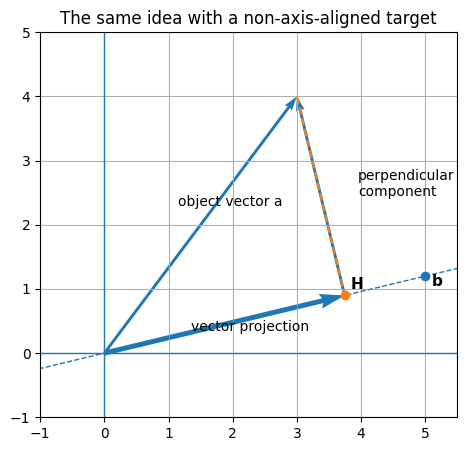

In [6]:
a = np.array([3, 4])
b = np.array([5, 1.2])

unit_b = b / np.linalg.norm(b)
scalar_projection = a @ unit_b
vector_projection = scalar_projection * unit_b
perpendicular_component = a - vector_projection

fig, ax = setup_vector_plot(xlim=(-1, 5.5), ylim=(-1, 5), figsize=(5.5, 5))

# Line through b, extended beyond the vector itself
line_scale = np.linspace(-0.25, 1.35, 100)
line_points = np.outer(line_scale, b)
ax.plot(line_points[:, 0], line_points[:, 1], linestyle="--", linewidth=1)

# Main visual pieces
draw_vector(ax, a, width=0.007)
draw_vector(ax, vector_projection, width=0.012)
draw_vector(ax, perpendicular_component, origin=vector_projection, width=0.007)

# Perpendicular guide
draw_dashed_line(ax, a, vector_projection)

# Key points
ax.scatter(b[0], b[1], zorder=4)
ax.scatter(vector_projection[0], vector_projection[1], zorder=4)

# Manual labels
ax.text(1.15, 2.3, "object vector a", fontsize=10)
ax.text(1.35, 0.35, "vector projection", fontsize=10)
ax.text(3.95, 2.45, "perpendicular\ncomponent", fontsize=10)

ax.text(b[0] + 0.1, b[1] - 0.15, "b", fontsize=11, fontweight="bold")
ax.text(
    vector_projection[0] + 0.1,
    vector_projection[1] + 0.1,
    "H",
    fontsize=11,
    fontweight="bold",
)

ax.set_title("The same idea with a non-axis-aligned target")
plt.show()

This example is less visually convenient, but it is the real point of the method.

The projection still lands on the line through the target vector.

The perpendicular leftover is still at right angles to the target vector.

And the object vector is still reconstructed by adding the two components:

$$
a = a_{\parallel} + a_{\perp}
$$

## Projection as a rotated-axis idea

Another useful mental model is to imagine temporarily treating the target vector as the main axis.

Suppose we rotated our coordinate system so that \(b\) pointed along the positive x-axis, or \(\hat{i}\) direction.

In that temporary coordinate system, the object vector \(a\) would have:

- one component along \(b\)
- one component sideways from \(b\)

The projection is the “along \(b\)” part, expressed back in the original coordinate system.

So projection is like asking:

> If the target vector were my main axis, how much of the object vector would lie along that axis?

This is only an intuition. We do not actually need to rotate the plane to calculate the projection.

## Scalar projection

The scalar projection tells us the signed length of the part of \(a\) that lies in the direction of \(b\).

It is calculated as:

$$
\operatorname{scalarproj}_{b}(a) =
\frac{a \cdot b}{\|b\|}
$$

Equivalently, if \(\hat{b}\) is the unit vector in the direction of \(b\):

$$
\operatorname{scalarproj}_{b}(a) =
a \cdot \hat{b}
$$

This gives a number, not a vector.

In [7]:
unit_b = b / np.linalg.norm(b)
scalar_projection = a @ unit_b

print("unit_b:", unit_b)
print("scalar projection of a onto b:", scalar_projection)

unit_b: [0.9723873  0.23337295]
scalar projection of a onto b: 3.8506537158428493


The scalar projection is `4.0`.

That makes sense visually. The object vector \(a = [4, 3]\) moves 4 units in the x direction, and the target vector \(b = [5, 0]\) points exactly along the x-axis.

So the signed length of the part of \(a\) that lies in the direction of \(b\) is 4.

## Vector projection

The vector projection turns the scalar projection back into a vector.

We take the signed length along \(b\), then multiply by the unit vector in the direction of \(b\):

$$
\operatorname{proj}_{b}(a) =
(a \cdot \hat{b})\hat{b}
$$

Another common form is:

$$
\operatorname{proj}_{b}(a) =
\frac{a \cdot b}{b \cdot b}b
$$

These are equivalent.

The first form says:

> find the signed length along the target direction, then point that length in the target direction.

The second form avoids explicitly naming the unit vector.

In [8]:
vector_projection_using_unit_b = (a @ unit_b) * unit_b
vector_projection_using_b = ((a @ b) / (b @ b)) * b

print("using unit_b:", vector_projection_using_unit_b)
print("using b directly:", vector_projection_using_b)

using unit_b: [3.74432678 0.89863843]
using b directly: [3.74432678 0.89863843]


Both calculations give the same result:

$$
\operatorname{proj}_{b}(a) = [4, 0]
$$

In this example:

- scalar projection = `4.0`
- vector projection = `[4, 0]`

The scalar version is just the signed length.

The vector version includes the direction as well.

## Projection and the triangle picture

There is also a useful triangle picture.

Imagine the triangle with these vertices:

- \(O\): the origin
- \(A\): the end of the object vector \(a\)
- \(B\): the end of the target vector \(b\)

The vector \(b\) forms the base direction.

The object vector \(a\) forms another side of the triangle.

The projection is **not** the height of the triangle.

Instead, it is the vector from the origin to the point where the perpendicular from \(A\) intersects the line through \(b\).

So if \(H\) is the foot of that perpendicular:

$$
\operatorname{proj}_{b}(a) = \overrightarrow{OH}
$$

The height is the leftover perpendicular part:

$$
a - \operatorname{proj}_{b}(a) = \overrightarrow{HA}
$$

In the axis-aligned example, this is especially clear:

$$
a = [4, 3]
$$

$$
\operatorname{proj}_{b}(a) = [4, 0]
$$

$$
a - \operatorname{proj}_{b}(a) = [0, 3]
$$

The projection tells us where the perpendicular from \(a\) lands on the target/base line.

The perpendicular component gives the height direction.

## Parallel and perpendicular components

Projection lets us split one vector into two parts:

$$
a = a_{\parallel} + a_{\perp}
$$

Where:

$$
a_{\parallel} = \operatorname{proj}_{b}(a)
$$

and:

$$
a_{\perp} = a - \operatorname{proj}_{b}(a)
$$

The parallel component lies along the target direction.

The perpendicular component is at right angles to the target direction.

In [9]:
parallel_component = projection_of(a, b)
perpendicular_component = a - parallel_component

print("a:", a)
print("parallel component:", parallel_component)
print("perpendicular component:", perpendicular_component)
print("parallel + perpendicular:", parallel_component + perpendicular_component)

a: [3 4]
parallel component: [3.74432678 0.89863843]
perpendicular component: [-0.74432678  3.10136157]
parallel + perpendicular: [3. 4.]


The object vector has been split into:

$$
[4, 3] = [4, 0] + [0, 3]
$$

That is visually obvious in this axis-aligned example, but the same logic works for any target direction.

## Checking the decomposition

If the perpendicular component is genuinely perpendicular to the target vector, their dot product should be zero.

This is because perpendicular vectors have cosine similarity zero, and therefore dot product zero.

In [10]:
dot_perpendicular_with_b = perpendicular_component @ b

print("perpendicular component:", perpendicular_component)
print("target vector b:", b)
print("perpendicular · b:", dot_perpendicular_with_b)

perpendicular component: [-0.74432678  3.10136157]
target vector b: [5.  1.2]
perpendicular · b: -8.881784197001252e-16


The result is zero.

That confirms that the leftover component is perpendicular to the target direction.

## Height of the triangle

When using \(b\) as the base direction of the triangle, the height is the length of the perpendicular component:

$$
\text{height} = \left\|a - \operatorname{proj}_{b}(a)\right\|
$$

For the current example, the perpendicular component is \([0, 3]\), so the height is 3.

In [11]:
height = np.linalg.norm(perpendicular_component)

print("height:", height)

height: 3.1894303504960972


The area of the triangle formed by \(a\) and \(b\) can then be calculated using the usual triangle area formula:

$$
\text{area} = \frac{1}{2} \times \text{base} \times \text{height}
$$

Here, the base length is \(\|b\|\).

In [12]:
base = np.linalg.norm(b)
area = 0.5 * base * height

print("base:", base)
print("height:", height)
print("area:", area)

base: 5.141984052872976
height: 3.1894303504960972
area: 8.2


In [13]:
a = np.array([2, 3])
b = np.array([5, 1])

parallel_component = projection_of(a, b)
perpendicular_component = perpendicular_component_of(a, b)

print("object vector a:", a)
print("target vector b:", b)
print("projection of a onto b:", parallel_component)
print("perpendicular leftover:", perpendicular_component)
print("a reconstructed:", parallel_component + perpendicular_component)
print("perpendicular · b:", perpendicular_component @ b)

object vector a: [2 3]
target vector b: [5 1]
projection of a onto b: [2.5 0.5]
perpendicular leftover: [-0.5  2.5]
a reconstructed: [2. 3.]
perpendicular · b: 0.0


## Why this matters for least squares

Projection is not just a geometry trick.

In least squares problems, we often cannot hit a target exactly. Instead, we find the closest reachable approximation.

That idea can be understood using projection:

- the reachable approximation is the projected part
- the error or residual is the perpendicular leftover

In this notebook’s language:

$$
\text{object vector} =
\text{projection} +
\text{perpendicular leftover}
$$

In least squares language, this becomes something like:

$$
\text{target} =
\text{best approximation} +
\text{residual}
$$

The residual being perpendicular is the key geometric idea behind least squares.

## Summary

Projection splits one vector relative to the direction of another vector.

The **scalar projection** is a signed number:

$$
\operatorname{scalarproj}_{b}(a) =
\frac{a \cdot b}{\|b\|}
$$

The **vector projection** is a vector:

$$
\operatorname{proj}_{b}(a) =
\frac{a \cdot b}{b \cdot b}b
$$

The vector projection is the target-aligned part of the object vector.

The perpendicular component is the leftover:

$$
a - \operatorname{proj}_{b}(a)
$$

Together, they reconstruct the original object vector:

$$
a =
\operatorname{proj}_{b}(a) +
\left(a - \operatorname{proj}_{b}(a)\right)
$$

The projection can also be understood geometrically:

> it is where the object vector lands on the target/base line when dropped perpendicularly.